# 1. Introduction

Your goal is to build an automated Sentiment Analysis System to classify incoming product reviews as Positive or Negative

# 2. Data Cleaning & Preprocessing

In [1]:
import nltk
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import string 
import re      

In [4]:
df = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/amazonreviews.tsv" , sep = "\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [5]:
df_original = df.copy()

In [6]:
df.shape

(10000, 2)

In [7]:
df.loc[0]['review']

'Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'

In [8]:
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

Dataset contains balanced data

a.Convert to lowercase

In [9]:
df['review'] = df['review'].str.lower()
df.head()

,label,review
0,pos,stuning even for the non-gamer: this sound tra...
1,pos,the best soundtrack ever to anything.: i'm rea...
2,pos,amazing!: this soundtrack is my favorite music...
3,pos,excellent soundtrack: i truly like this soundt...
4,pos,"remember, pull your jaw off the floor after he..."


b.Remove stopwords

In [10]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [11]:
def remove_stopwords(x):
    lst = nltk.word_tokenize(x)
    new_lst = [x for x in lst if x not in stop_words]
    return ' '.join(new_lst)

In [12]:
df['review'] = df['review'].apply(remove_stopwords)
df['review'].head(2)

0    stuning even non-gamer : sound track beautiful...
1    best soundtrack ever anything . : 'm reading l...
Name: review, dtype: object

c.Remove all punctuations

In [13]:
puncts = string.punctuation
puncts

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
df['review'] = df['review'].str.replace('[{}]'.format(puncts), ' ' , regex=True)
df['review'].head()

0    stuning even non gamer   sound track beautiful...
1    best soundtrack ever anything      m reading l...
2    amazing     soundtrack favorite music time   h...
3    excellent soundtrack   truly like soundtrack e...
4    remember   pull jaw floor hearing    ve played...
Name: review, dtype: object

d.Removing urls , special characters and emoji's

In [15]:
def clean_text(text):
    text = re.sub(r'[^\w\s]' ,'',text)
    text = re.sub(r"http\S+|www\S+|https\S+" , " ", text)
    return text

In [16]:
df['review'] = df['review'].apply(clean_text)
df['review'].head()

0    stuning even non gamer   sound track beautiful...
1    best soundtrack ever anything      m reading l...
2    amazing     soundtrack favorite music time   h...
3    excellent soundtrack   truly like soundtrack e...
4    remember   pull jaw floor hearing    ve played...
Name: review, dtype: object

e.Remove duplicates

In [17]:
df.drop_duplicates(inplace=True)

f.Handle missing values

In [18]:
df.dropna(subset=['review'], inplace=True)

e.Lemmetize the text

In [19]:
from nltk.stem import WordNetLemmatizer

In [20]:
lem  = WordNetLemmatizer() 

In [21]:
def lemmatize(x):
    lem_lst = []
    lst = x.split()
    for word in lst:
        lem_lst.append(lem.lemmatize(word))
    return ' '.join(lem_lst)          

In [22]:
df['review'] = df['review'].apply(lemmatize)
df['review'].head()

0    stuning even non gamer sound track beautiful p...
1    best soundtrack ever anything m reading lot re...
2    amazing soundtrack favorite music time hand in...
3    excellent soundtrack truly like soundtrack enj...
4    remember pull jaw floor hearing ve played game...
Name: review, dtype: object

e.encode categorical data

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])
df.tail(3)

,label,review
9997,0,interesting subject poor presentation d hard p...
9998,0,n t buy box looked used obviously new tried co...
9999,1,beautiful pen fast delivery pen shipped prompt...


# 3. Exploratory Data Analysis (EDA)

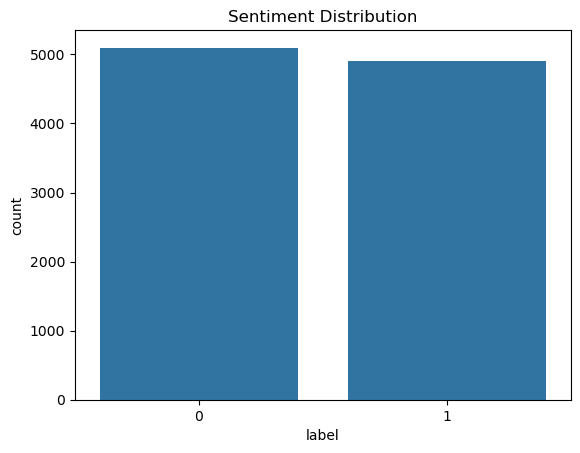

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

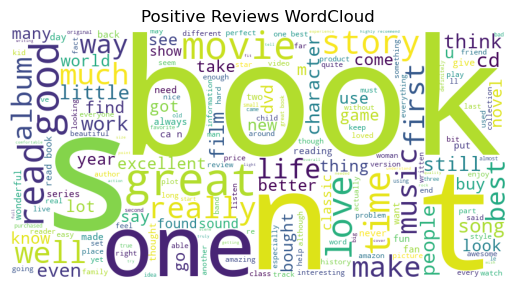

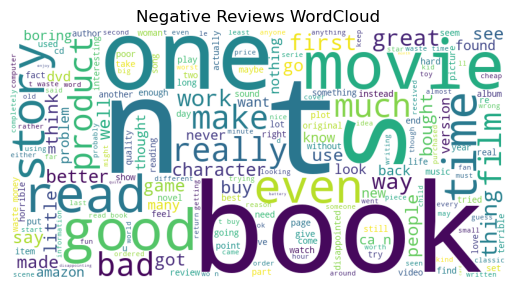

In [26]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['label']==1]['review'])
negative_text = ' '.join(df[df['label']==0]['review'])

# Positive
wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

# Negative
wc = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

Observation

- Positive reviews contains words like book,great,album ,good ,go,real,book,love,movie,story,read,music,album
- Negative  reviews contains words like book,look,bad,movie,product,read,story,time,boring

# 4. Feature Engineering (TF-IDF)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['review']).toarray()
y = df['label']

# 5. Train/Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((8000, 28370), (2000, 28370), (8000,), (2000,))

# 6. Model Training

a.Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report, accuracy_score

In [30]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [31]:
yhat_train = model.predict(X_train)

In [32]:
cm = confusion_matrix(y_train , yhat_train)
cm

array([[3782,  278],
       [ 256, 3684]], dtype=int64)

In [33]:
print(classification_report(y_train , yhat_train))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      4060
           1       0.93      0.94      0.93      3940

    accuracy                           0.93      8000
   macro avg       0.93      0.93      0.93      8000
weighted avg       0.93      0.93      0.93      8000



In [34]:
yhat_test = model.predict(X_test)

# 7. Evaluation

In [35]:
cm = confusion_matrix(y_test , yhat_test)
cm

array([[887, 150],
       [149, 814]], dtype=int64)

In [36]:
print(classification_report(y_test , yhat_test))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.84      0.85      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



# 8. Cross Validation

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.8370000000000001


With logistic Regression , we have accuracy of 85% and F1_score is 84%, which is a good score

b.Support Vector Machine

In [38]:
tfidf = TfidfVectorizer(max_features=5000)

from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

LinearSVC()

In [39]:
yhatSVM_train = svm_model.predict(X_train)

In [40]:
cm = confusion_matrix(y_train , yhatSVM_train)
cm

array([[4029,   31],
       [  27, 3913]], dtype=int64)

In [41]:
print(classification_report(y_train , yhatSVM_train))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4060
           1       0.99      0.99      0.99      3940

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



In [42]:
yhatSVM_test = svm_model.predict(X_test)

In [43]:
cm = confusion_matrix(y_test , yhatSVM_test)
cm

array([[883, 154],
       [141, 822]], dtype=int64)

In [44]:
print(classification_report(y_test , yhatSVM_test))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1037
           1       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [45]:
# cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm_model, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.8297000000000001


Observations:

- Both SVM and Logistic Regression performs well and giving 85% of accuracy which is quite a good score

c.Word2Vec

In [46]:
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
tokenized_reviews = [word_tokenize(i.lower()) for i in df['review']]

In [47]:
# Train Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,   # embedding size
    window=5,
    min_count=2,
    workers=4
)

In [48]:
def get_review_vector(review):
    words = review.split()
    word_vectors = []
    
    for word in words:
        if word in w2v_model.wv:
            word_vectors.append(w2v_model.wv[word])
    
    if len(word_vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    
    return np.mean(word_vectors, axis=0)

# Apply to dataset
X_w2v = np.array(df['review'].apply(get_review_vector).tolist())
y = df['label']

In [49]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

In [50]:
model = LogisticRegression(max_iter=500)
model.fit(X_train2, y_train2)

y_pred2 = model.predict(X_test2)

print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75      1037
           1       0.73      0.69      0.71       963

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



Due to less amount of training data, accuracy of Word2vec is 73%

## Creating a pipeline

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [52]:
sent_ppl = Pipeline([
    ('tfidf',TfidfVectorizer()),
    ('lreg',LogisticRegression(max_iter=400))
])

In [53]:
X_new = df['review']
y_new = df['label']

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((8000,), (2000,), (8000,), (2000,))

In [54]:
sent_ppl.fit(X_new,y_new)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('lreg', LogisticRegression(max_iter=400))])

In [55]:
sent_ppl.predict(X_train)

array([1, 0, 1, ..., 0, 0, 0])

In [56]:
text = 'Watching this movie is waste of time and money'
sent_ppl.predict([text])

array([0])

# Conclusion

This system enables real-time monitoring of customer sentiment, allowing the company to quickly identify declining product quality or customer dissatisfaction. It can also be integrated into dashboards to alert product teams when negative sentiment spikes

- Most reviews are positive
- Negative reviews contain words like:
 "bad", "waste", "poor", "disappointed"
- Positive reviews contain:
"excellent", "amazing", "best", "love"
Model achieved:
- Accuracy: ~85–95%
- Good balance in precision/recall